In [ ]:
# Extra libraries installed in /scratch
import sys
sys.path.insert(0, '/scratch/network/ih2422/lib')

# Importing functions from other files
from narratives.narratives_utils import *

In [2]:
# Fetch data for 21st year story (hence abbreviated as "twenty")
twenty_segments   = fetch_segments("21styear")
twenty_subjects = fetch_subject_list("21styear")
print(f"{len(twenty_subjects)} twenty subjects: {twenty_subjects}")

# Fetch data for tunnel story
tunnel_segments   = fetch_segments("tunnel")
tunnel_subjects = fetch_subject_list("tunnel", exclude_subjects=["sub-004", "sub-013"])
print(f"{len(tunnel_subjects)} tunnel subjects: {tunnel_subjects}")

25 twenty subjects: ['sub-075', 'sub-131', 'sub-190', 'sub-201', 'sub-235', 'sub-244', 'sub-249', 'sub-254', 'sub-255', 'sub-256', 'sub-257', 'sub-258', 'sub-259', 'sub-260', 'sub-261', 'sub-262', 'sub-263', 'sub-264', 'sub-265', 'sub-266', 'sub-267', 'sub-268', 'sub-269', 'sub-270', 'sub-271']
21 tunnel subjects: ['sub-001', 'sub-005', 'sub-022', 'sub-025', 'sub-026', 'sub-041', 'sub-052', 'sub-053', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066', 'sub-069']


### 1. Place Annotation (with Claude)

In [3]:
# Tunnel story places
tunnel_places = annotate_places(
    "Tunnel Under the World", fetch_whisperx_transcript("tunnel"),
    ["guy_home", "bus", "office"],
    out_dir / "tunnel_places.tsv"
)

tunnel_places.tsv already exists — skipping API call.


   41.9s  [guy_home]  In the kitchen, cooking breakfast.
   78.6s  [bus]  Coming in on the bus,
  126.9s  [office]  the gigantic Contro Chemical building,
  224.2s  [guy_home]  got ready for bed.
  325.8s  [bus]  took the usual bus to work.
  376.4s  [office]  The speaker in the elevator
  647.5s  [guy_home]  Guy Burkhart went home
  813.8s  [bus]  Guy Burkhardt got on his bus.
  859.1s  [other]  Burkhardt. Here, behind the fence.


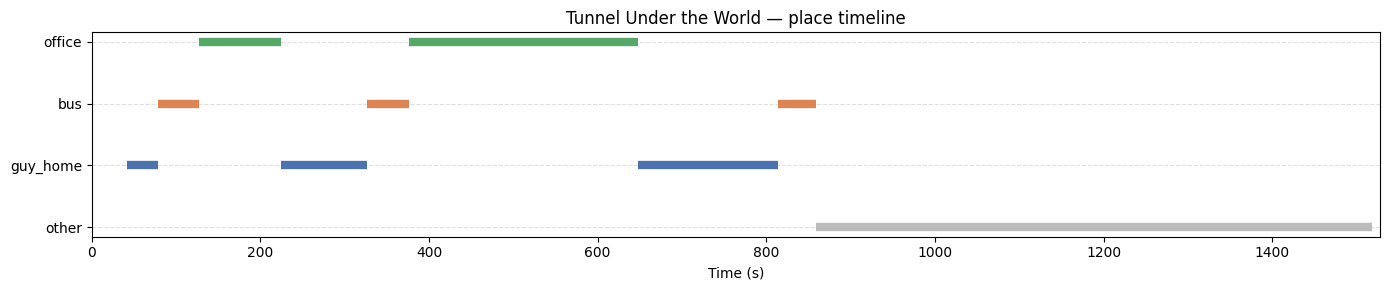

1517.97


In [70]:
tunnel_colors = {"guy_home": "#4C72B0", "bus": "#DD8452", "office": "#55A868", "other": "#bbbbbb"}

tunnel_aligned = align_tsv_to_whisperx(Path("tunnel_places.tsv"), tunnel_segments, fetch_whisperx_transcript("tunnel"))

plot_place_line(tunnel_aligned, "Tunnel Under the World — place timeline",
                ["guy_home", "bus", "office"], tunnel_colors)

In [ ]:
def plot_place_line_2(aligned_rows, title, place_order, place_colors):
    label_to_y = {p: i for i, p in enumerate(place_order)}

    fig, ax = plt.subplots(figsize=(14, 3))
    for row in aligned_rows[:-1]:
        y = label_to_y.get(row["place"], -1)
        color = place_colors.get(row["place"], "#aaaaaa")
        ax.plot([row["start"], row["start"]+15], [y, y], color=color, linewidth=6, solid_capstyle="butt")

    ax.set_yticks(list(range(len(place_order))))
    ax.set_yticklabels(place_order)
    ax.set_xlabel("Time (s)")
    ax.set_title(title)
    ax.set_xlim(left=0, right=aligned_rows[-1]["end"] + 10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(aligned_rows[-1]["end"])

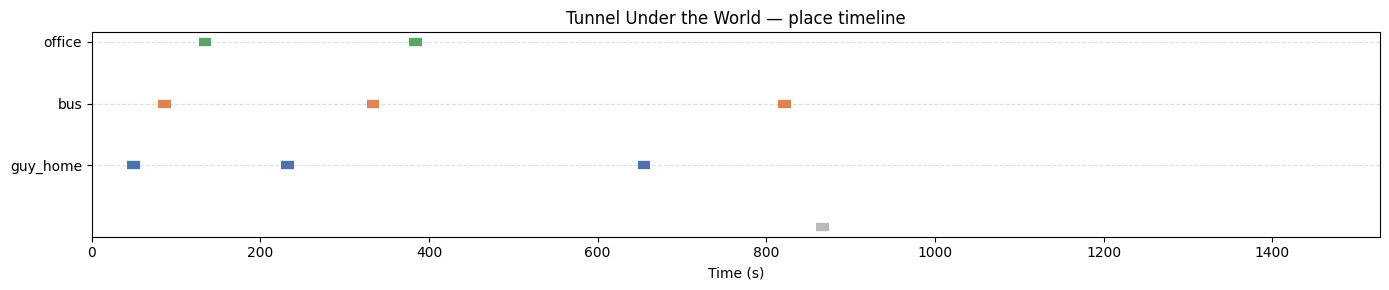

1517.97


In [78]:
plot_place_line_2(tunnel_aligned, "Tunnel Under the World — place timeline",
                ["guy_home", "bus", "office"], tunnel_colors)

In [5]:
tunnel_aligned

[{'place': 'guy_home',
  'start': 41.855,
  'excerpt': 'In the kitchen, cooking breakfast.',
  'end': 78.614},
 {'place': 'bus',
  'start': 78.614,
  'excerpt': 'Coming in on the bus,',
  'end': 126.901},
 {'place': 'office',
  'start': 126.901,
  'excerpt': 'the gigantic Contro Chemical building,',
  'end': 224.216},
 {'place': 'guy_home',
  'start': 224.216,
  'excerpt': 'got ready for bed.',
  'end': 325.807},
 {'place': 'bus',
  'start': 325.807,
  'excerpt': 'took the usual bus to work.',
  'end': 376.447},
 {'place': 'office',
  'start': 376.447,
  'excerpt': 'The speaker in the elevator',
  'end': 647.532},
 {'place': 'guy_home',
  'start': 647.532,
  'excerpt': 'Guy Burkhart went home',
  'end': 813.766},
 {'place': 'bus',
  'start': 813.766,
  'excerpt': 'Guy Burkhardt got on his bus.',
  'end': 859.107},
 {'place': 'other',
  'start': 859.107,
  'excerpt': 'Burkhardt. Here, behind the fence.',
  'end': 1517.97}]

### Single-Subject Analysis: Tunnel Story

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [55]:
import tphate
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.maskers import NiftiMasker
from nilearn.image import resample_to_img

TR          = 1.5
HRF_LAG_TRS = 3

# Build place-network mask (PPA + OPA + RSC) from Schaefer 400-17
_mni   = datasets.load_mni152_brain_mask(resolution=4)
_sch   = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=17, resolution_mm=2)
_lbls  = [l.decode() if isinstance(l, bytes) else l for l in _sch.labels]
_rm    = NiftiMasker(mask_img=_mni, standardize=True); _rm.fit()
_simg  = resample_to_img(_sch.maps, _rm.mask_img_, interpolation='nearest')
_sdata = _simg.get_fdata().astype(int)
_mdata = _rm.mask_img_.get_fdata().astype(bool)
_pl    = {i + 1: l for i, l in enumerate(_lbls)}

_net_vol = np.zeros(_sdata.shape, dtype=bool)
for _idx, _lbl in _pl.items():
    if any(s in _lbl for s in ["PHC", "Rsp", "DorsAttnA_TempOcc", "DorsAttnB_TempOcc"]):
        _net_vol |= (_sdata == _idx)
_place_net_mask = (_net_vol & _mdata)[_mdata]
print(f"Place network voxels: {_place_net_mask.sum()}")

# Load BOLD for first subject
sub  = tunnel_subjects[0]
data = load_bold_masked(sub, "tunnel", _mni, standardize=True)
net  = data[:, _place_net_mask]
n_trs = net.shape[0]
print(f"Subject: {sub}  |  shape: {net.shape}")

# Label each TR by HRF-shifted event label
def _label_trs(n_trs, aligned_rows, TR, lag_trs):
    labels = np.array(["other"] * n_trs, dtype=object)
    for row in aligned_rows:
        s = max(0, min(int(row["start"] / TR) + lag_trs, n_trs))
        e = max(s, min(int(row["end"]   / TR) + lag_trs, n_trs))
        labels[s:e] = row["place"]
    return labels

tr_labels = _label_trs(n_trs, tunnel_aligned, TR, HRF_LAG_TRS)

# Fit T-PHATE (smacof solver — s_gd2 incompatible with NumPy 2.x)
tphate_op = tphate.TPHATE(
    n_components=2, t="auto", smooth_window=4,
    mds_solver="smacof", n_jobs=-1, verbose=1
)
emb = tphate_op.fit_transform(net)
print(f"Optimal t = {tphate_op.optimal_t},  ACF dropoff = {tphate_op.dropoff}")

[fetch_atlas_schaefer_2018] Dataset found in /home/ih2422/nilearn_data/schaefer_2018

Place network voxels: 871
[cache] loading sub-001_task-tunnel_std.npy
Subject: sub-001  |  shape: (1040, 871)
Calculating TPHATE...
  Running TPHATE on 1040 observations and 871 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 32.68 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.31 seconds.
    Calculating affinities...
    Calculated affinities in 0.04 seconds.
  Calculated graph and diffusion operator in 33.05 seconds.
  Learning the autocorrelation function...
  Calculating Autocorr kernel...
    Dropoff point: 7
  Combining PHATE operator and autocorr operator
  Calculating optimal t...
    Automatically selected t = 7
  Calculated optimal t in 153.30 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 3.70 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 15.62 seconds.
Calculated TPHATE in 206.71 seconds.
Optimal t = 7,  ACF dropoff = 7


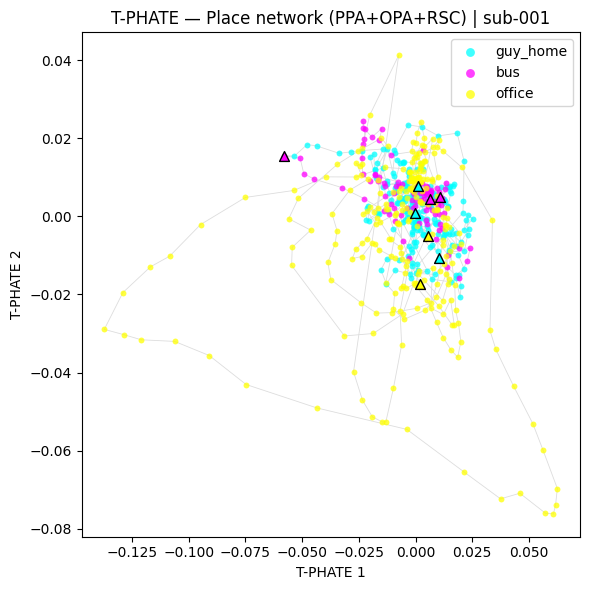

In [61]:
# ── Plot: full trajectory with event scatter, segment means, onsets/offsets ───
event_labels = ["guy_home", "bus", "office"]
event_idx    = np.where(np.isin(tr_labels, event_labels))[0]
tunnel_colors = {"guy_home": "cyan", "bus": "magenta", "office": "yellow", "other": "#bbbbbb"}

# Per-segment: mean embedding + onset/offset TR indices
event_means   = []
onset_idx, offset_idx, onset_labels = [], [], []
for row in tunnel_aligned:
    if row["place"] not in event_labels:
        continue
    s = max(0, min(int(row["start"] / TR) + HRF_LAG_TRS, n_trs))
    e = max(s, min(int(row["end"]   / TR) + HRF_LAG_TRS, n_trs))
    s_i = s
    e_i = max(s, e - 1)
    onset_idx.append(s_i)
    offset_idx.append(e_i)
    onset_labels.append(row["place"])
    if e > s:
        seg_emb = emb[s:e]
        event_means.append((row["place"], seg_emb[:, 0].mean(), seg_emb[:, 1].mean()))

fig, ax = plt.subplots(figsize=(6, 6))

# Lines only between consecutive event TRs
for i in range(len(emb) - 1):
    if tr_labels[i] in event_labels and tr_labels[i + 1] in event_labels:
        ax.plot(emb[i:i+2, 0], emb[i:i+2, 1],
                color="#dddddd", linewidth=0.6, zorder=1)

# Body of each event
for label in event_labels:
    idx = np.where(tr_labels == label)[0]
    ax.scatter(emb[idx, 0], emb[idx, 1],
               c=tunnel_colors[label], s=18, label=label,
               alpha=0.75, linewidths=0, zorder=2)

# Onsets — upward triangles
for s_i, label in zip(onset_idx, onset_labels):
    ax.scatter(emb[s_i, 0], emb[s_i, 1], s=50, marker="^",
               c=tunnel_colors[label], edgecolors="black", linewidths=1.0, zorder=4)

# # Offsets — downward triangles
# for e_i, label in zip(offset_idx, onset_labels):
#     ax.scatter(emb[e_i, 0], emb[e_i, 1], s=50, marker="v",
#                c=tunnel_colors[label], edgecolors="black", linewidths=1.0, zorder=4)

# # Event means — large circles
# for place, mx, my in event_means:
#     ax.scatter(mx, my, s=100, c=tunnel_colors[place],
#                edgecolors="black", linewidths=1.5, zorder=5)

ax.set_xlabel("T-PHATE 1")
ax.set_ylabel("T-PHATE 2")
ax.set_title(f"T-PHATE — Place network (PPA+OPA+RSC) | {sub}")
ax.legend(markerscale=1.5, framealpha=0.8)
plt.tight_layout()
plt.show()


[cache] loading sub-001_task-tunnel_std.npy
[cache] loading sub-005_task-tunnel_std.npy
[cache] loading sub-022_task-tunnel_std.npy
[cache] loading sub-025_task-tunnel_std.npy
[cache] loading sub-026_task-tunnel_std.npy
[cache] loading sub-041_task-tunnel_std.npy
[cache] loading sub-052_task-tunnel_std.npy
[cache] loading sub-053_task-tunnel_std.npy
[cache] loading sub-055_task-tunnel_std.npy
[cache] loading sub-056_task-tunnel_std.npy
[cache] loading sub-057_task-tunnel_std.npy
[cache] loading sub-058_task-tunnel_std.npy
[cache] loading sub-059_task-tunnel_std.npy
[cache] loading sub-060_task-tunnel_std.npy
[cache] loading sub-061_task-tunnel_std.npy
[cache] loading sub-062_task-tunnel_std.npy
[cache] loading sub-063_task-tunnel_std.npy
[cache] loading sub-064_task-tunnel_std.npy
[cache] loading sub-065_task-tunnel_std.npy
[cache] loading sub-066_task-tunnel_std.npy
[cache] loading sub-069_task-tunnel_std.npy
Subject ISC (mean r across voxels):
  sub-066  r=0.0057  <-- LOW ISC
  sub-0

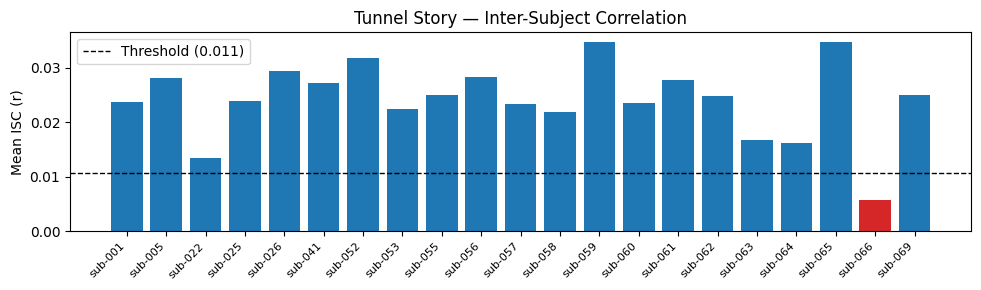

In [9]:
# ISC-based attention filter (Hasson et al., 2004)
from nilearn import datasets

_mni = datasets.load_mni152_brain_mask(resolution=4)
isc_scores, tunnel_subjects_filtered = isc_filter(
    tunnel_subjects, "tunnel", _mni,
    title="Tunnel Story — Inter-Subject Correlation"
)


[fetch_atlas_schaefer_2018] Dataset found in /home/ih2422/nilearn_data/schaefer_2018

PPA voxels: 208  |  TPJ voxels: 32
[cache] loading sub-001_task-tunnel_std.npy
[cache] loading sub-005_task-tunnel_std.npy
[cache] loading sub-022_task-tunnel_std.npy
[cache] loading sub-025_task-tunnel_std.npy
[cache] loading sub-026_task-tunnel_std.npy
[cache] loading sub-041_task-tunnel_std.npy
[cache] loading sub-052_task-tunnel_std.npy
[cache] loading sub-053_task-tunnel_std.npy
[cache] loading sub-055_task-tunnel_std.npy
[cache] loading sub-056_task-tunnel_std.npy
[cache] loading sub-057_task-tunnel_std.npy
[cache] loading sub-058_task-tunnel_std.npy
[cache] loading sub-059_task-tunnel_std.npy
[cache] loading sub-060_task-tunnel_std.npy
[cache] loading sub-061_task-tunnel_std.npy
[cache] loading sub-062_task-tunnel_std.npy
[cache] loading sub-063_task-tunnel_std.npy
[cache] loading sub-064_task-tunnel_std.npy
[cache] loading sub-065_task-tunnel_std.npy
[cache] loading sub-069_task-tunnel_std.npy
Computing PPA ISC...
Computing TPJ ISC...


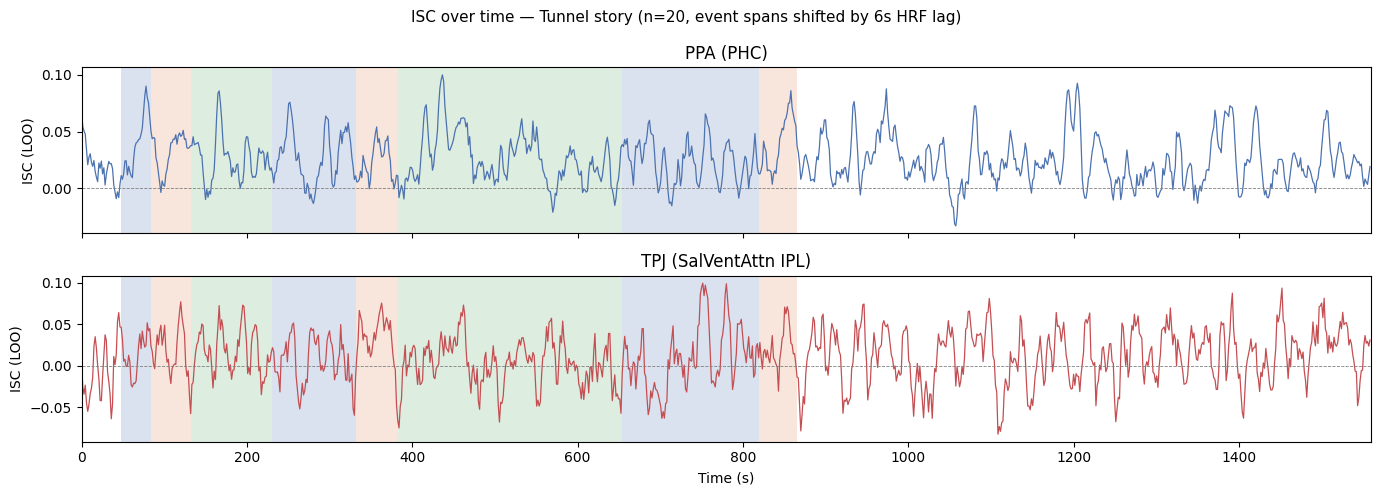

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from nilearn import datasets
from nilearn.maskers import NiftiMasker
from nilearn.image import resample_to_img

_TR          = 1.5
_HRF_LAG_TRS = 4
_HRF_LAG_S   = _HRF_LAG_TRS * _TR   # 6 s — shift event spans to align with BOLD

_mni = datasets.load_mni152_brain_mask(resolution=4)
_schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=17, resolution_mm=2)
_labels = [l.decode() if isinstance(l, bytes) else l for l in _schaefer.labels]
_rm = NiftiMasker(mask_img=_mni, standardize=True); _rm.fit()
_sdata = resample_to_img(_schaefer.maps, _rm.mask_img_, interpolation='nearest').get_fdata().astype(int)
_mdata = _rm.mask_img_.get_fdata().astype(bool)

def _build_mask(searches):
    vol = np.zeros(_sdata.shape, dtype=bool)
    for _idx, _lbl in enumerate(_labels, start=1):
        if any(s in _lbl for s in searches):
            vol |= (_sdata == _idx)
    return (vol & _mdata)[_mdata]

_ppa_mask = _build_mask(["PHC"])
_tpj_mask = _build_mask(["SalVentAttn_IPL", "SalVentAttnA_IPL", "SalVentAttnB_IPL"])
print(f"PPA voxels: {_ppa_mask.sum()}  |  TPJ voxels: {_tpj_mask.sum()}")

# Load time series for filtered subjects
_ppa_data, _tpj_data = [], []
for sub in tunnel_subjects_filtered:
    d = load_bold_masked(sub, 'tunnel', _mni, standardize=True)
    if d is not None:
        _ppa_data.append(d[:, _ppa_mask])
        _tpj_data.append(d[:, _tpj_mask])

n_subs = len(_ppa_data)
n_trs  = _ppa_data[0].shape[0]

def _loo_isc(data_list):
    n = len(data_list)
    t = data_list[0].shape[0]
    isc = np.zeros(t)
    for tr in range(t):
        patterns = np.array([d[tr] for d in data_list])
        vals = []
        for i in range(n):
            mean_others = np.delete(patterns, i, axis=0).mean(axis=0)
            vals.append(np.corrcoef(patterns[i], mean_others)[0, 1])
        isc[tr] = np.mean(vals)
    return isc

print("Computing PPA ISC...")
isc_ppa = uniform_filter1d(_loo_isc(_ppa_data), size=5)
print("Computing TPJ ISC...")
isc_tpj = uniform_filter1d(_loo_isc(_tpj_data), size=5)

time_axis = np.arange(n_trs) * _TR

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, isc, title, color in zip(axes,
                                  [isc_ppa, isc_tpj],
                                  ['PPA (PHC)', 'TPJ (SalVentAttn IPL)'],
                                  ['#4C72B0', '#C44E52']):
    ax.plot(time_axis, isc, color=color, linewidth=0.9)
    for row in tunnel_aligned:
        if row['place'] in tunnel_colors and row['place'] != 'other':
            ax.axvspan(row['start'] + _HRF_LAG_S, row['end'] + _HRF_LAG_S,
                       alpha=0.2, color=tunnel_colors[row['place']], linewidth=0)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    ax.set_ylabel('ISC (LOO)')
    ax.set_title(title)
    ax.set_xlim(0, n_trs * _TR)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'ISC over time — Tunnel story (n={n_subs}, event spans shifted by {_HRF_LAG_S:.0f}s HRF lag)', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut
from nilearn.maskers import NiftiMasker
from nilearn import datasets
from nilearn.image import resample_to_img
import numpy as np

TR  = 1.5
HRF_LAG_TRS = 4

mni_mask = datasets.load_mni152_brain_mask(resolution=4)
schaefer  = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=17, resolution_mm=2)
labels    = [l.decode() if isinstance(l, bytes) else l for l in schaefer.labels]

labeled_places = ["guy_home", "bus", "office"]
events = [r for r in tunnel_aligned if r["place"] in labeled_places]

def event_pattern(event, bold, TR, lag_trs):
    start_tr = int(event["start"] / TR) + lag_trs
    end_tr   = int(event["end"]   / TR) + lag_trs
    start_tr, end_tr = start_tr, start_tr + 10
    start_tr = max(0, min(start_tr, len(bold) - 1))
    end_tr   = max(start_tr + 1, min(end_tr, len(bold)))
    return bold[start_tr:end_tr].mean(axis=0)

# Encode labels once — same for every subject
le = LabelEncoder()
y_encoded = le.fit_transform([e["place"] for e in events])

# Build atlas and ROI masks once — atlas is subject-independent
ref_masker = NiftiMasker(mask_img=mni_mask, standardize=True)
ref_masker.fit()
schaefer_img  = resample_to_img(schaefer.maps, ref_masker.mask_img_, interpolation='nearest')
schaefer_data = schaefer_img.get_fdata().astype(int)
mask_data     = ref_masker.mask_img_.get_fdata().astype(bool)

parcel_label = {i + 1: lbl for i, lbl in enumerate(labels)}

roi_masks = {}
for roi, searches in [("PHC", ["PHC"]), ("Rsp", ["Rsp"]), ("OPA", ["DorsAttnA_TempOcc", "DorsAttnB_TempOcc"]),
                       ("mPFC", ["DefaultA_PFCm"]), ("AG", ["DefaultB_IPL", "DefaultC_IPL"]),
                       ("PMC", ["_pCun"]),
                       ("A1", ["SomMotB_Aud"]), ("V1", ["Striate"]), ("S1", ["SomMotA"])]:
    vol = np.zeros(schaefer_data.shape, dtype=bool)
    for idx, lbl in parcel_label.items():
        if any(s in lbl for s in searches):
            vol |= (schaefer_data == idx)
    roi_masks[roi] = vol & mask_data

subject_acc = {}

for sub_i in tunnel_subjects_filtered:
    data_i = load_bold_masked(sub_i, "tunnel", mni_mask, standardize=True)
    if data_i is None:
        print(f"{sub_i}  — file missing, skipping")
        continue

    stimulus_duration = data_i.shape[0] * TR

    X_i = np.vstack([event_pattern(e, data_i, TR, HRF_LAG_TRS) for e in events])
    y_i = y_encoded

    pipe_wb = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    LinearSVC(max_iter=10000))
    ])

    loo = LeaveOneOut()
    preds_wb = np.zeros(len(X_i), dtype=int)
    for train_idx, test_idx in loo.split(X_i):
        pipe_wb.fit(X_i[train_idx], y_i[train_idx])
        preds_wb[test_idx[0]] = pipe_wb.predict(X_i[test_idx])[0]
    acc_wb = np.mean(preds_wb == y_i)

    # ROI accuracies (no feature selection — ROIs already small)
    roi_accs = {}
    for roi, roi_mask in roi_masks.items():
        voxels   = data_i[:, roi_mask[mask_data]]
        X_roi    = np.vstack([event_pattern(e, voxels, TR, HRF_LAG_TRS) for e in events])
        pipe_roi = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(max_iter=10000))
        ])
        preds_roi = np.zeros(len(X_roi), dtype=int)
        for train_idx, test_idx in loo.split(X_roi):
            pipe_roi.fit(X_roi[train_idx], y_i[train_idx])
            preds_roi[test_idx[0]] = pipe_roi.predict(X_roi[test_idx])[0]
        roi_accs[roi] = np.mean(preds_roi == y_i)

    subject_acc[sub_i] = {"wb": acc_wb, "PHC": roi_accs["PHC"], "Rsp": roi_accs["Rsp"], "OPA": roi_accs["OPA"], "mPFC": roi_accs["mPFC"], "AG": roi_accs["AG"], "PMC": roi_accs["PMC"], "A1": roi_accs["A1"], "V1": roi_accs["V1"], "S1": roi_accs["S1"]}
    print(f"{sub_i}  dur={stimulus_duration:.1f}s  whole-brain={acc_wb:.2f}  PHC={roi_accs['PHC']:.2f}  Rsp={roi_accs['Rsp']:.2f}  OPA={roi_accs['OPA']:.2f}  mPFC={roi_accs['mPFC']:.2f}  AG={roi_accs['AG']:.2f}  PMC={roi_accs['PMC']:.2f}  A1={roi_accs['A1']:.2f}  V1={roi_accs['V1']:.2f}  S1={roi_accs['S1']:.2f}")

chance = 1 / len(le.classes_)
mean_wb   = np.mean([v["wb"]   for v in subject_acc.values()])
mean_phc  = np.mean([v["PHC"]  for v in subject_acc.values()])
mean_rsp  = np.mean([v["Rsp"]  for v in subject_acc.values()])
mean_opa  = np.mean([v["OPA"]  for v in subject_acc.values()])
mean_mpfc = np.mean([v["mPFC"] for v in subject_acc.values()])
mean_ag   = np.mean([v["AG"]   for v in subject_acc.values()])
mean_pmc  = np.mean([v["PMC"]  for v in subject_acc.values()])
mean_a1   = np.mean([v["A1"]   for v in subject_acc.values()])
mean_v1   = np.mean([v["V1"]   for v in subject_acc.values()])
mean_s1   = np.mean([v["S1"]   for v in subject_acc.values()])
print(f"\nMean  whole-brain={mean_wb:.2f}  PHC={mean_phc:.2f}  Rsp={mean_rsp:.2f}  OPA={mean_opa:.2f}  mPFC={mean_mpfc:.2f}  AG={mean_ag:.2f}  PMC={mean_pmc:.2f}  A1={mean_a1:.2f}  V1={mean_v1:.2f}  S1={mean_s1:.2f}  (chance={chance:.2f})")
print(f"Above chance (wb): {sum(v['wb'] > chance for v in subject_acc.values())}/{len(subject_acc)} subjects")

[cache] loading sub-001_task-tunnel_std.npy


Parcels decoded: 400  (chance=0.33)
Best:  17Networks_RH_DorsAttnA_ParOcc_2  acc=1.00
Worst: 17Networks_LH_VisPeri_StriCal_2  acc=0.00


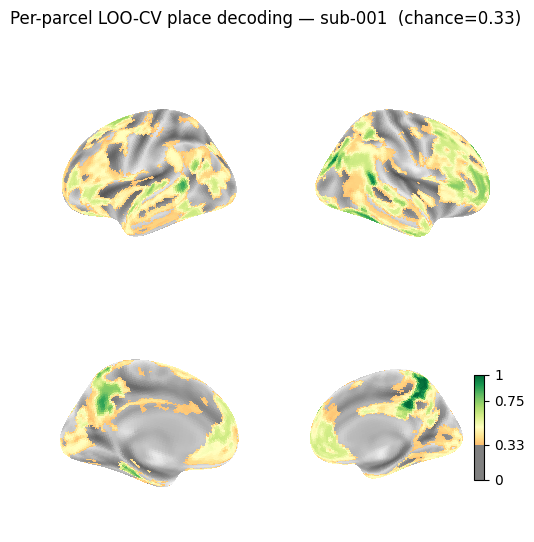

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Subject to plot ───────────────────────────────────────────────────────────
surf_sub  = tunnel_subjects_filtered[0]
data_sub  = load_bold_masked(surf_sub, "tunnel", mni_mask, standardize=True)

y      = np.array([e["place"] for e in events])
chance = 1 / len(labeled_places)
pipe   = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])

# ── Per-parcel LOO-CV ─────────────────────────────────────────────────────────
parcel_acc = {}
for parcel_idx in range(1, len(labels) + 1):
    parcel_mask = (schaefer_data == parcel_idx) & mask_data
    if parcel_mask.sum() < 5:
        continue
    X_p = np.array([event_pattern(e, data_sub[:, parcel_mask[mask_data]], TR, HRF_LAG_TRS)
                    for e in events])
    preds = []
    for i in range(len(X_p)):
        train = [j for j in range(len(X_p)) if j != i]
        pipe.fit(X_p[train], y[train])
        preds.append(pipe.predict(X_p[[i]])[0])
    parcel_acc[parcel_idx] = np.mean(np.array(preds) == y)

best  = max(parcel_acc, key=parcel_acc.get)
worst = min(parcel_acc, key=parcel_acc.get)
print(f"Parcels decoded: {len(parcel_acc)}  (chance={chance:.2f})")
print(f"Best:  {parcel_label[best]}  acc={parcel_acc[best]:.2f}")
print(f"Worst: {parcel_label[worst]}  acc={parcel_acc[worst]:.2f}")

# ── Build result volume ───────────────────────────────────────────────────────
result_vol = np.zeros(schaefer_data.shape)
for idx, acc in parcel_acc.items():
    result_vol[schaefer_data == idx] = acc
result_img = new_img_like(schaefer_img, result_vol)

# ── Surface plot ──────────────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(6, 6))
fig.suptitle(f'Per-parcel LOO-CV place decoding — {surf_sub}  (chance={chance:.2f})', fontsize=12)

for i, (hemi, view) in enumerate([('left','lateral'), ('right','lateral'),
                                    ('left','medial'),  ('right','medial')]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn', vmax=1.0, threshold=chance,
        colorbar=(i == 3), symmetric_cbar=False,
        axes=ax,
    )

plt.show()

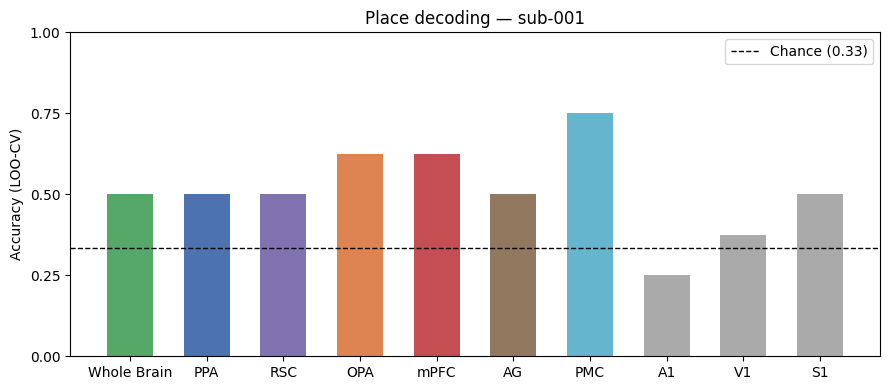

In [37]:
import numpy as np
import matplotlib.pyplot as plt

sub1   = tunnel_subjects_filtered[0]
acc    = subject_acc[sub1]
chance = 1 / len(labeled_places)

rois   = ["wb",          "PHC",  "Rsp",  "OPA",  "mPFC",  "AG",     "PMC",   "A1",    "V1",    "S1"]
labels = ["Whole Brain", "PPA",  "RSC",  "OPA",  "mPFC",  "AG",     "PMC",   "A1",    "V1",    "S1"]
colors = ["#55A868",     "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]
values = [acc[r] for r in rois]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, values, color=colors, width=0.6)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Place decoding — {sub1}')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()


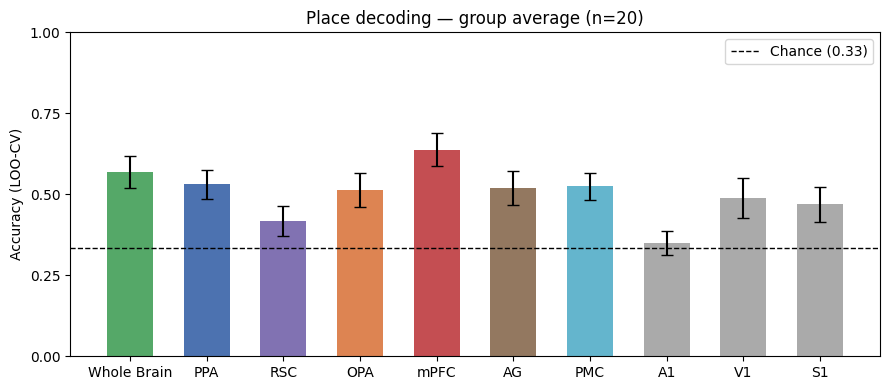

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

chance = 1 / len(labeled_places)

rois   = ["wb",          "PHC",   "Rsp",    "OPA",    "mPFC",   "AG",     "PMC",    "A1",      "V1",      "S1"]
labels = ["Whole Brain", "PPA",   "RSC",    "OPA",    "mPFC",   "AG",     "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868",     "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]

means = [np.mean([v[r] for v in subject_acc.values()]) for r in rois]
sems  = [stats.sem([v[r] for v in subject_acc.values()]) for r in rois]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, means, yerr=sems, color=colors, width=0.6,
       capsize=4, error_kw=dict(elinewidth=1.5))
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Place decoding — group average (n={len(subject_acc)})')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()


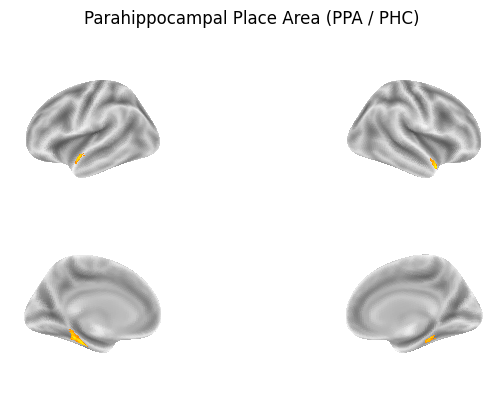

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like

# PPA (PHC) sentinel volume — constant value where PHC parcels are
ppa_vol = np.zeros(schaefer_data.shape)
for idx, lbl in parcel_label.items():
    if "PHC" in lbl:
        ppa_vol[schaefer_data == idx] = 1.0

ppa_img = new_img_like(schaefer_img, ppa_vol)

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(8, 4))
fig.suptitle('Parahippocampal Place Area (PPA / PHC)', fontsize=12)

for i, (hemi, view) in enumerate([('left', 'lateral'), ('right', 'lateral'),
                                    ('left', 'medial'),  ('right', 'medial')]):
    texture = surface.vol_to_surf(ppa_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='autumn', threshold=0.5, vmax=1.0,
        colorbar=False,
        axes=ax,
    )

plt.tight_layout()
plt.show()


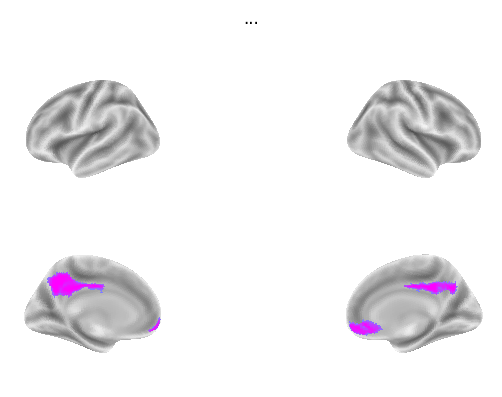

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like

# TPJ (SalVentAttn IPL) sentinel volume
tpj_vol = np.zeros(schaefer_data.shape)
for idx, lbl in parcel_label.items():
    if "pCunPCC" in lbl:
        tpj_vol[schaefer_data == idx] = 1.0

tpj_img = new_img_like(schaefer_img, tpj_vol)

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(8, 4))
fig.suptitle('...', fontsize=12)

for i, (hemi, view) in enumerate([('left', 'lateral'), ('right', 'lateral'),
                                    ('left', 'medial'),  ('right', 'medial')]):
    texture = surface.vol_to_surf(tpj_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='cool', threshold=0.5, vmax=1.0,
        colorbar=False,
        axes=ax,
    )

plt.tight_layout()
plt.show()


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y      = np.array([e["place"] for e in events])
chance = 1 / len(labeled_places)
pipe   = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])

# ── Per-parcel LOO-CV averaged across subjects ────────────────────────────────
parcel_acc_all = {}   # parcel_idx -> list of per-subject accuracies

for sub in tunnel_subjects_filtered:
    data_sub = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    if data_sub is None:
        continue
    for parcel_idx in range(1, len(labels) + 1):
        parcel_mask = (schaefer_data == parcel_idx) & mask_data
        if parcel_mask.sum() < 5:
            continue
        X_p = np.array([event_pattern(e, data_sub[:, parcel_mask[mask_data]], TR, HRF_LAG_TRS)
                        for e in events])
        preds = []
        for i in range(len(X_p)):
            train = [j for j in range(len(X_p)) if j != i]
            pipe.fit(X_p[train], y[train])
            preds.append(pipe.predict(X_p[[i]])[0])
        parcel_acc_all.setdefault(parcel_idx, []).append(np.mean(np.array(preds) == y))
    print(f"{sub} done")

parcel_acc_mean = {idx: np.mean(accs) for idx, accs in parcel_acc_all.items()}

best  = max(parcel_acc_mean, key=parcel_acc_mean.get)
worst = min(parcel_acc_mean, key=parcel_acc_mean.get)
print(f"\nParcels decoded: {len(parcel_acc_mean)}  (chance={chance:.2f})")
print(f"Best:  {parcel_label[best]}  acc={parcel_acc_mean[best]:.2f}")
print(f"Worst: {parcel_label[worst]}  acc={parcel_acc_mean[worst]:.2f}")

# ── Build result volume ───────────────────────────────────────────────────────
result_vol = np.zeros(schaefer_data.shape)
for idx, acc in parcel_acc_mean.items():
    result_vol[schaefer_data == idx] = acc
result_img = new_img_like(schaefer_img, result_vol)

# ── Surface plot ──────────────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(6, 6))
fig.suptitle(f'Per-parcel LOO-CV place decoding — group average (n={len(tunnel_subjects_filtered)}, chance={chance:.2f})', fontsize=12)

for i, (hemi, view) in enumerate([('left','lateral'), ('right','lateral'),
                                    ('left','medial'),  ('right','medial')]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn', vmax=1.0, threshold=chance,
        colorbar=(i == 3), symmetric_cbar=False,
        axes=ax,
    )

plt.show()

[cache] loading sub-001_task-tunnel_std.npy


KeyboardInterrupt: 

[cache] loading sub-001_task-tunnel_std.npy
sub-001 done
[cache] loading sub-005_task-tunnel_std.npy
sub-005 done
[cache] loading sub-022_task-tunnel_std.npy
sub-022 done
[cache] loading sub-025_task-tunnel_std.npy
sub-025 done
[cache] loading sub-026_task-tunnel_std.npy
sub-026 done
[cache] loading sub-041_task-tunnel_std.npy
sub-041 done
[cache] loading sub-052_task-tunnel_std.npy
sub-052 done
[cache] loading sub-053_task-tunnel_std.npy
sub-053 done
[cache] loading sub-055_task-tunnel_std.npy
sub-055 done
[cache] loading sub-056_task-tunnel_std.npy
sub-056 done
[cache] loading sub-057_task-tunnel_std.npy
sub-057 done
[cache] loading sub-058_task-tunnel_std.npy
sub-058 done
[cache] loading sub-059_task-tunnel_std.npy
sub-059 done
[cache] loading sub-060_task-tunnel_std.npy
sub-060 done
[cache] loading sub-061_task-tunnel_std.npy
sub-061 done
[cache] loading sub-062_task-tunnel_std.npy
sub-062 done
[cache] loading sub-063_task-tunnel_std.npy
sub-063 done
[cache] loading sub-064_task-tu

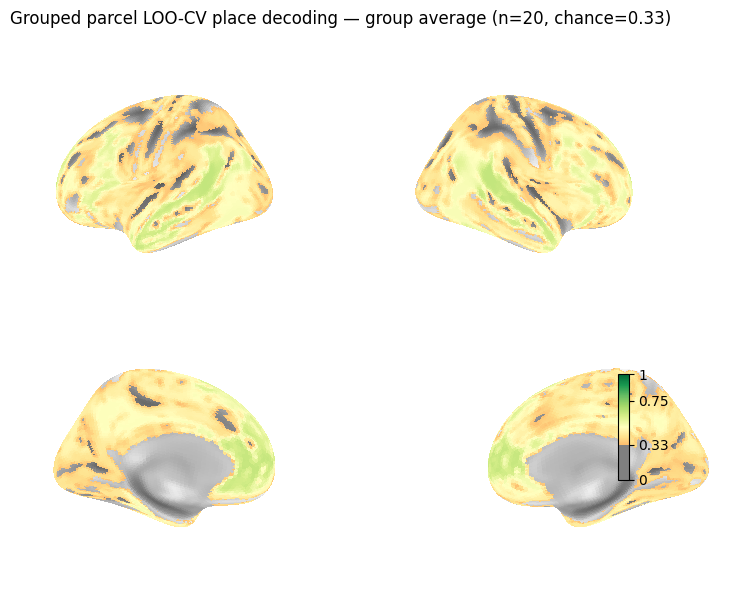

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def parcel_to_group(lbl):
    lbl = re.sub(r'^17Networks_[LR]H_', '', lbl)
    lbl = re.sub(r'_\d+$', '', lbl)
    return lbl

# Build parcel_idx -> group mapping (skip Background parcel)
parcel_groups = {}
for idx, lbl in parcel_label.items():
    g = parcel_to_group(lbl)
    if g != 'Background':
        parcel_groups[idx] = g

# group -> list of parcel indices
group_parcels = {}
for idx, g in parcel_groups.items():
    group_parcels.setdefault(g, []).append(idx)

y      = np.array([e["place"] for e in events])
chance = 1 / len(labeled_places)
pipe   = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])

# ── Per-group LOO-CV averaged across subjects ─────────────────────────────────
group_acc_all = {g: [] for g in group_parcels}

for sub in tunnel_subjects_filtered:
    data_sub = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    if data_sub is None:
        continue
    for g, idxs in group_parcels.items():
        vol = np.zeros(schaefer_data.shape, dtype=bool)
        for idx in idxs:
            vol |= (schaefer_data == idx)
        group_mask = (vol & mask_data)[mask_data]
        if group_mask.sum() < 5:
            continue
        X_p = np.array([event_pattern(e, data_sub[:, group_mask], TR, HRF_LAG_TRS)
                        for e in events])
        preds = []
        for i in range(len(X_p)):
            train = [j for j in range(len(X_p)) if j != i]
            pipe.fit(X_p[train], y[train])
            preds.append(pipe.predict(X_p[[i]])[0])
        group_acc_all[g].append(np.mean(np.array(preds) == y))
    print(f"{sub} done")

group_acc_mean = {g: np.mean(accs) for g, accs in group_acc_all.items() if accs}
print()
for g, acc in sorted(group_acc_mean.items(), key=lambda x: -x[1])[:10]:
    print(f"  {g}: {acc:.3f}")

# ── Build result volume ───────────────────────────────────────────────────────
result_vol = np.zeros(schaefer_data.shape)
for idx, g in parcel_groups.items():
    if g in group_acc_mean:
        result_vol[schaefer_data == idx] = group_acc_mean[g]
result_img = new_img_like(schaefer_img, result_vol)

# ── Surface plot ──────────────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(8, 6))
fig.suptitle(f'Grouped parcel LOO-CV place decoding — group average (n={len(tunnel_subjects_filtered)}, chance={chance:.2f})', fontsize=12)

for i, (hemi, view) in enumerate([('left','lateral'), ('right','lateral'),
                                    ('left','medial'),  ('right','medial')]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn', vmax=1.0, threshold=chance,
        colorbar=(i == 3), symmetric_cbar=False,
        axes=ax,
    )

plt.tight_layout()
plt.show()


In [21]:
import numpy as np
from statsmodels.stats.multitest import multipletests

N_PERM = 10000
rng = np.random.default_rng(42)

chance = 1 / len(labeled_places)


def permutation_test_mean(accs, chance, n_perm=10000):
    """
    Fully non-parametric one-sided test:
    H1: mean(accs) > chance
    """
    accs = np.array(accs)
    obs = accs.mean()

    # center under null
    centered = accs - chance

    # sign-flip permutations (valid under symmetry assumption)
    signs = rng.choice([-1, 1], size=(n_perm, len(accs)))
    null_dist = (signs * centered).mean(axis=1)

    # one-sided p-value
    p = (null_dist >= obs - chance).mean()

    return obs, p


group_names = []
mean_accs = []
p_vals = []

for g, accs in group_acc_all.items():
    if len(accs) < 2:
        continue

    mean_acc, p = permutation_test_mean(accs, chance, N_PERM)

    group_names.append(g)
    mean_accs.append(mean_acc)
    p_vals.append(p)

group_names = np.array(group_names)
mean_accs = np.array(mean_accs)
p_vals = np.array(p_vals)

# FDR correction across parcels
reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.01, method='fdr_bh')

print(f"{reject.sum()} / {len(reject)} parcels significant (FDR q=0.01)\n")

for g, m, p, r in sorted(zip(group_names, mean_accs, p_fdr, reject), key=lambda x: -x[1]):
    mark = "✓" if r else " "
    print(f"{mark} {g:<25s} mean_acc={m:.3f}  p_fdr={p:.3f}")

19 / 60 parcels significant (FDR q=0.01)

✓ TempPar                   mean_acc=0.644  p_fdr=0.000
✓ DefaultA_PFCm             mean_acc=0.637  p_fdr=0.000
✓ DefaultB_Temp             mean_acc=0.619  p_fdr=0.000
✓ DefaultB_IPL              mean_acc=0.594  p_fdr=0.001
✓ DefaultB_PFCd             mean_acc=0.594  p_fdr=0.000
✓ DefaultB_PFCv             mean_acc=0.581  p_fdr=0.000
✓ ContA_PFCl                mean_acc=0.569  p_fdr=0.001
✓ ContB_PFClv               mean_acc=0.544  p_fdr=0.000
✓ DefaultC_PHC              mean_acc=0.531  p_fdr=0.001
✓ DorsAttnA_ParOcc          mean_acc=0.525  p_fdr=0.001
✓ DorsAttnA_TempOcc         mean_acc=0.519  p_fdr=0.004
✓ SalVentAttnA_FrMed        mean_acc=0.512  p_fdr=0.001
✓ LimbicA_TempPole          mean_acc=0.506  p_fdr=0.009
  ContA_PFCd                mean_acc=0.506  p_fdr=0.016
✓ DefaultA_pCunPCC          mean_acc=0.506  p_fdr=0.007
  ContB_PFCld               mean_acc=0.506  p_fdr=0.016
✓ DefaultA_IPL              mean_acc=0.500  p_fdr=0.009
✓ Defa

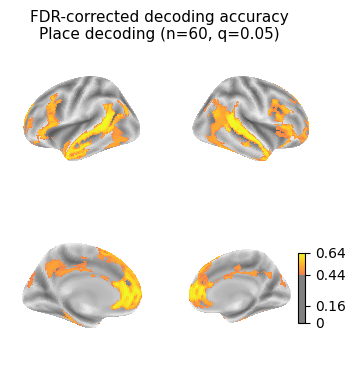

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like

# ── Build volume (use mean accuracy instead of t-values) ─────────────────────
result_vol = np.full(schaefer_data.shape, np.nan)

for g, acc, r in zip(group_names, mean_accs, reject):
    if not r:
        continue
    for idx, grp in parcel_groups.items():
        if grp == g:
            result_vol[schaefer_data == idx] = acc

# Replace NaNs with 0 for plotting
result_vol_plot = np.where(np.isnan(result_vol), 0, result_vol)
result_img = new_img_like(schaefer_img, result_vol_plot)

# ── Surface projection ───────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

fig = plt.figure(figsize=(4, 4))
fig.suptitle(
    f'FDR-corrected decoding accuracy\nPlace decoding '
    f'(n=60, q=0.05)',
    fontsize=11
)

# threshold = smallest significant effect
acc_min = mean_accs[reject].min() if reject.any() else 0.0

for i, (hemi, view) in enumerate([
    ('left', 'lateral'),
    ('right', 'lateral'),
    ('left', 'medial'),
    ('right', 'medial')
]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])

    ax = fig.add_subplot(2, 2, i + 1, projection='3d')

    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'],
        texture,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='plasma',
        threshold=acc_min,
        colorbar=(i == 3),
        symmetric_cbar=False,
        axes=ax,
    )

plt.show()

In [16]:
raise NotImplementedError("Above code is a work in progress")

NotImplementedError: Above code is a work in progress

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

wb_accs  = [v["wb"]  for v in subject_acc.values()]
phc_accs = [v["PHC"] for v in subject_acc.values()]
opa_accs = [v["OPA"] for v in subject_acc.values()]
chance   = 1 / 3

means = [np.mean(wb_accs), np.mean(phc_accs), np.mean(opa_accs)]
sems  = [stats.sem(wb_accs), stats.sem(phc_accs), stats.sem(opa_accs)]

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(3)
ax.bar(x, means, yerr=sems, capsize=5,
       color=["#55A868", "#4C72B0", "#DD8452"], width=0.5, error_kw=dict(elinewidth=1.5))
ax.axhline(chance, color="black", linestyle="--", linewidth=1, label=f"Chance ({chance:.2f})")
ax.set_xticks(x)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticklabels(["Whole Brain", "PPA", "OPA"])
ax.set_ylabel("Accuracy (LOO-CV)")
ax.set_title("Tunnel Story — Decoding (n={})".format(len(subject_acc)))
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import permutation_test_score
import numpy as np
import matplotlib.pyplot as plt

n_permutations = 10

_pipe_perm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=10000))
])

obs_scores      = []
perm_scores_all = []

for sub_i in tunnel_subjects_filtered:
    data_i = load_bold_masked(sub_i, "tunnel", mni_mask, standardize=True)
    if data_i is None:
        continue
    X_i = np.vstack([event_pattern(e, data_i, TR, HRF_LAG_TRS) for e in events])
    score, perm_scores, p_value = permutation_test_score(
        _pipe_perm, X_i, y_encoded,
        cv=LeaveOneOut(), n_permutations=n_permutations,
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    obs_scores.append(score)
    perm_scores_all.append(perm_scores)
    print(f"{sub_i}  obs={score:.3f}  p={p_value:.4f}")

null_dist = np.stack(perm_scores_all).mean(axis=0)
mean_obs  = np.mean(obs_scores)
p_pooled  = (null_dist >= mean_obs).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_dist, bins=30, color='#aaaaaa', edgecolor='white', label='Null (permuted labels)')
ax.axvline(mean_obs, color='#d62728', linewidth=2, label=f'Observed mean = {mean_obs:.3f}')
ax.axvline(1/3, color='k', linestyle='--', linewidth=1, label='Chance (0.33)')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test — Tunnel story, whole-brain (n={len(obs_scores)} subjects)\n'
             f'p = {p_pooled:.4f} ({n_permutations} permutations)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
import numpy as np

# ── Method 1: t-test across subjects ─────────────────────────────────────────
# Each subject's LOO-CV accuracy is one independent observation.
# Tests whether the group mean is significantly above chance (1/3).
# No permutations needed — the 20 subjects are the replications.
wb_accs = [v["wb"] for v in subject_acc.values()]
t_stat, p_t = stats.ttest_1samp(wb_accs, 1/3)
print(f"One-sample t-test vs chance (1/3):  n={len(wb_accs)}")
print(f"  mean={np.mean(wb_accs):.3f}  sem={stats.sem(wb_accs):.3f}")
print(f"  t({len(wb_accs)-1}) = {t_stat:.3f},  p = {p_t:.2e}")

# ── Method 2: Sign test ───────────────────────────────────────────────────────
# How likely is it to see k/n subjects above chance by chance alone?
n_above = sum(a > 1/3 for a in wb_accs)
p_binom = stats.binomtest(n_above, len(wb_accs), p=1/3, alternative='greater').pvalue
print(f"\nSign test: {n_above}/{len(wb_accs)} subjects above chance")
print(f"  binomial p = {p_binom:.2e}")

# ── Method 3: Combined permutation null ──────────────────────────────────────
# Average the per-subject null distributions from the cell above.
# CLT: with 20 subjects, the null mean tightens around chance,
# so even moderate observed accuracy lands far in the tail.
combined_null = np.stack(perm_scores_all).mean(axis=0)
mean_obs = np.mean(obs_scores)
p_perm = (combined_null >= mean_obs).mean()
print(f"\nCombined permutation null (n_perm={len(combined_null)}):")
print(f"  null mean={combined_null.mean():.3f}  null std={combined_null.std():.4f}")
print(f"  observed mean={mean_obs:.3f},  p = {p_perm:.4f}")

[cache] loading sub-001_task-tunnel_std.npy
[cache] loading sub-005_task-tunnel_std.npy
[cache] loading sub-022_task-tunnel_std.npy
[cache] loading sub-025_task-tunnel_std.npy
[cache] loading sub-026_task-tunnel_std.npy
[cache] loading sub-041_task-tunnel_std.npy
[cache] loading sub-052_task-tunnel_std.npy
[cache] loading sub-053_task-tunnel_std.npy
[cache] loading sub-055_task-tunnel_std.npy
[cache] loading sub-056_task-tunnel_std.npy
[cache] loading sub-057_task-tunnel_std.npy
[cache] loading sub-058_task-tunnel_std.npy
[cache] loading sub-059_task-tunnel_std.npy
[cache] loading sub-060_task-tunnel_std.npy
[cache] loading sub-061_task-tunnel_std.npy
[cache] loading sub-062_task-tunnel_std.npy
[cache] loading sub-063_task-tunnel_std.npy
[cache] loading sub-064_task-tunnel_std.npy
[cache] loading sub-065_task-tunnel_std.npy
[cache] loading sub-069_task-tunnel_std.npy


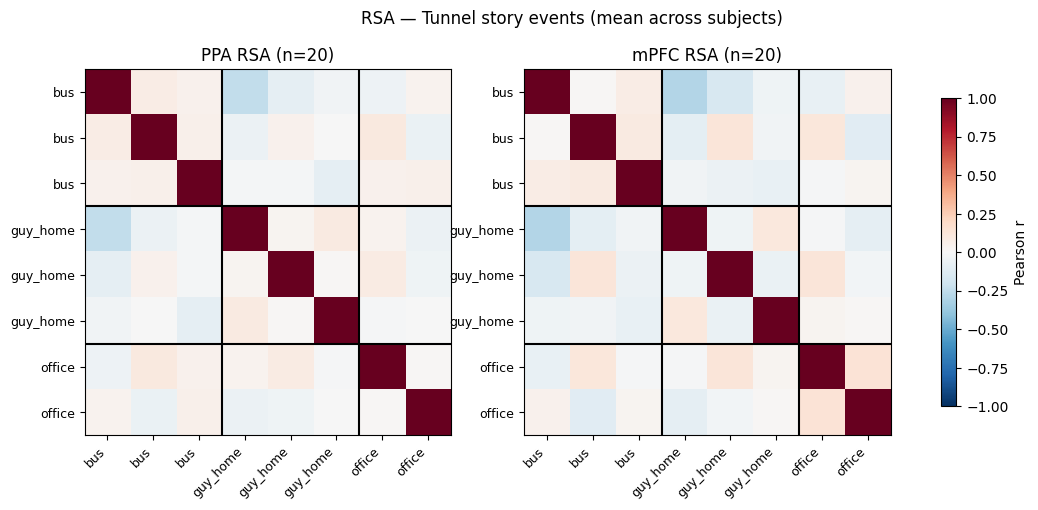

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Collect per-subject RSA matrices — PPA and mPFC
rsa_ppa_list  = []
rsa_mpfc_list = []

ppa_voxels  = roi_masks["PHC"][mask_data]
mpfc_voxels = roi_masks["mPFC"][mask_data]

for sub_i in tunnel_subjects_filtered:
    data_i = load_bold_masked(sub_i, 'tunnel', mni_mask, standardize=True)
    if data_i is None:
        continue
    X_ppa  = np.vstack([event_pattern(e, data_i[:, ppa_voxels],  TR, HRF_LAG_TRS) for e in events])
    X_mpfc = np.vstack([event_pattern(e, data_i[:, mpfc_voxels], TR, HRF_LAG_TRS) for e in events])
    rsa_ppa_list.append(np.corrcoef(X_ppa))
    rsa_mpfc_list.append(np.corrcoef(X_mpfc))

mean_ppa  = np.mean(rsa_ppa_list,  axis=0)
mean_mpfc = np.mean(rsa_mpfc_list, axis=0)

# Sort events by place label
place_labels = [e['place'] for e in events]
sort_order   = sorted(range(len(events)), key=lambda i: place_labels[i])
sorted_labels = [place_labels[i] for i in sort_order]

# Group boundary positions
counts, prev = [], None
for lbl in sorted_labels:
    if lbl != prev:
        counts.append(1); prev = lbl
    else:
        counts[-1] += 1

def _plot_rsa(ax, matrix, title):
    mat_sorted = matrix[np.ix_(sort_order, sort_order)]
    img = ax.imshow(mat_sorted, cmap='RdBu_r', vmin=-1, vmax=1)
    cum = 0
    for c in counts[:-1]:
        cum += c
        ax.axhline(cum - 0.5, color='k', linewidth=1.5)
        ax.axvline(cum - 0.5, color='k', linewidth=1.5)
    ax.set_xticks(range(len(sorted_labels)))
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(sorted_labels, fontsize=9)
    ax.set_title(title)
    return img

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_plot_rsa(axes[0], mean_ppa,  f'PPA RSA (n={len(rsa_ppa_list)})')
img = _plot_rsa(axes[1], mean_mpfc, f'mPFC RSA (n={len(rsa_mpfc_list)})')
fig.colorbar(img, ax=axes, label='Pearson r', shrink=0.8)
plt.suptitle('RSA — Tunnel story events (mean across subjects)', fontsize=12)
plt.show()


In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import LinearSVC
# from scipy import stats
# import numpy as np
# import matplotlib.pyplot as plt

# SRM_K    = 50
# SRM_ITER = 20

# # ── Deterministic SRM (no MPI) ────────────────────────────────────────────────
# # data_list: list of (voxels, TRs) arrays, all same shape
# # Returns W_list: list of (voxels, k) orthonormal weight matrices
# def fit_srm(data_list, k, n_iter):
#     n_subs = len(data_list)
#     rng    = np.random.RandomState(42)
#     W_list = []
#     for X in data_list:
#         A = rng.randn(X.shape[0], k)
#         U, _, Vt = np.linalg.svd(A, full_matrices=False)
#         W_list.append(U @ Vt)
#     for _ in range(n_iter):
#         S = sum(W.T @ X for W, X in zip(W_list, data_list)) / n_subs
#         W_list = []
#         for X in data_list:
#             U, _, Vt = np.linalg.svd(X @ S.T, full_matrices=False)
#             W_list.append(U @ Vt)
#     return W_list

# # ── Step 1: Fit SRM on "other" (non-event) TRs ───────────────────────────────
# def other_tr_mask(n_trs, events, TR, lag_trs):
#     mask = np.zeros(n_trs, dtype=bool)
#     for e in events:
#         s = max(0, min(int(e["start"] / TR) + lag_trs, n_trs - 1))
#         t = max(s + 1, min(int(e["end"]   / TR) + lag_trs, n_trs))
#         mask[s:t] = True
#     return ~mask

# srm_subs, srm_arrays = [], []
# for sub in tunnel_subjects_filtered:
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     if data is None:
#         continue
#     other = data[other_tr_mask(data.shape[0], events, TR, HRF_LAG_TRS)]
#     srm_subs.append(sub)
#     srm_arrays.append(other.T)

# min_trs    = min(a.shape[1] for a in srm_arrays)
# srm_arrays = [a[:, :min_trs] for a in srm_arrays]

# W_list = fit_srm(srm_arrays, k=SRM_K, n_iter=SRM_ITER)
# print(f"SRM fitted: k={SRM_K}, {min_trs} other TRs, {len(srm_subs)} subjects")

# # ── Step 2: Project event patterns into shared space ─────────────────────────
# X_shared = {}
# for i, sub in enumerate(srm_subs):
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     X_i  = np.vstack([event_pattern(e, data, TR, HRF_LAG_TRS) for e in events])
#     X_shared[sub] = X_i @ W_list[i]

# # ── Step 3: Leave-one-subject-out classification ─────────────────────────────
# loso_acc = {}
# for test_sub in srm_subs:
#     train_subs = [s for s in srm_subs if s != test_sub]
#     X_train = np.vstack([X_shared[s] for s in train_subs])
#     y_train = np.tile(y_encoded, len(train_subs))
#     pipe = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])
#     pipe.fit(X_train, y_train)
#     loso_acc[test_sub] = np.mean(pipe.predict(X_shared[test_sub]) == y_encoded)
#     print(f"{test_sub}  acc={loso_acc[test_sub]:.3f}")

# accs   = list(loso_acc.values())
# t_stat, p_val = stats.ttest_1samp(accs, 1/3)
# w_stat, p_wilcoxon = stats.wilcoxon(accs, [1/3]*len(accs), alternative='greater')
# print(f"Mean LOSO acc = {np.mean(accs):.3f} +/- {stats.sem(accs):.3f}")
# print(f"t({len(accs)-1}) = {t_stat:.3f},  p = {p_val:.2e}  (vs chance = 0.33)")
# print(f"Wilcoxon signed-rank: W={w_stat:.0f},  p={p_wilcoxon:.2e}")

# fig, ax = plt.subplots(figsize=(10, 3))
# colors = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs]
# ax.bar(srm_subs, accs, color=colors)
# ax.axhline(1/3, color="k", linestyle="--", linewidth=1, label="Chance (0.33)")
# ax.axhline(np.mean(accs), color="#d62728", linestyle="-", linewidth=1.5,
#            label=f"Mean={np.mean(accs):.2f}  t({len(accs)-1})={t_stat:.1f}  p={p_val:.1e}")
# ax.set_xticks(range(len(srm_subs)))
# ax.set_xticklabels(srm_subs, rotation=45, ha="right", fontsize=8)
# ax.set_ylabel("Accuracy")
# ax.set_title(f"LOSO cross-subject decoding with SRM (k={SRM_K}) — Tunnel story")
# ax.set_ylim(0, 1)
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# ppa_voxel_mask = roi_masks["PHC"][mask_data]   # boolean index into masked BOLD columns

# # ── SRM on PPA "other" TRs ────────────────────────────────────────────────────
# srm_subs_ppa, srm_arrays_ppa = [], []
# for sub in tunnel_subjects_filtered:
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     if data is None:
#         continue
#     ppa   = data[:, ppa_voxel_mask]
#     other = ppa[other_tr_mask(ppa.shape[0], events, TR, HRF_LAG_TRS)]
#     srm_subs_ppa.append(sub)
#     srm_arrays_ppa.append(other.T)

# min_trs_ppa    = min(a.shape[1] for a in srm_arrays_ppa)
# srm_arrays_ppa = [a[:, :min_trs_ppa] for a in srm_arrays_ppa]

# W_list_ppa = fit_srm(srm_arrays_ppa, k=SRM_K, n_iter=SRM_ITER)
# print(f"PPA SRM fitted: k={SRM_K}, {min_trs_ppa} other TRs, {srm_arrays_ppa[0].shape[0]} PPA voxels")

# # ── Project PPA event patterns into shared space ──────────────────────────────
# X_shared_ppa = {}
# for i, sub in enumerate(srm_subs_ppa):
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     ppa  = data[:, ppa_voxel_mask]
#     X_i  = np.vstack([event_pattern(e, ppa, TR, HRF_LAG_TRS) for e in events])
#     X_shared_ppa[sub] = X_i @ W_list_ppa[i]

# # ── LOSO classification ───────────────────────────────────────────────────────
# loso_acc_ppa = {}
# for test_sub in srm_subs_ppa:
#     train_subs = [s for s in srm_subs_ppa if s != test_sub]
#     X_train = np.vstack([X_shared_ppa[s] for s in train_subs])
#     y_train = np.tile(y_encoded, len(train_subs))
#     pipe = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])
#     pipe.fit(X_train, y_train)
#     loso_acc_ppa[test_sub] = np.mean(pipe.predict(X_shared_ppa[test_sub]) == y_encoded)
#     print(f"{test_sub}  acc={loso_acc_ppa[test_sub]:.3f}")

# accs_ppa = list(loso_acc_ppa.values())
# t_ppa, p_ppa = stats.ttest_1samp(accs_ppa, 1/3)
# w_ppa, p_w_ppa = stats.wilcoxon(accs_ppa, [1/3]*len(accs_ppa), alternative='greater')
# print(f"Mean LOSO acc (PPA) = {np.mean(accs_ppa):.3f} +/- {stats.sem(accs_ppa):.3f}")
# print(f"t({len(accs_ppa)-1}) = {t_ppa:.3f},  p = {p_ppa:.2e}  (vs chance = 0.33)")
# print(f"Wilcoxon signed-rank: W={w_ppa:.0f},  p={p_w_ppa:.2e}")

# fig, ax = plt.subplots(figsize=(10, 3))
# colors = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs_ppa]
# ax.bar(srm_subs_ppa, accs_ppa, color=colors)
# ax.axhline(1/3, color="k", linestyle="--", linewidth=1, label="Chance (0.33)")
# ax.axhline(np.mean(accs_ppa), color="#d62728", linestyle="-", linewidth=1.5,
#            label=f"Mean={np.mean(accs_ppa):.2f}  t({len(accs_ppa)-1})={t_ppa:.1f}  p={p_ppa:.1e}")
# ax.set_xticks(range(len(srm_subs_ppa)))
# ax.set_xticklabels(srm_subs_ppa, rotation=45, ha="right", fontsize=8)
# ax.set_ylabel("Accuracy")
# ax.set_title(f"LOSO cross-subject decoding with SRM (k={SRM_K}) — PPA only")
# ax.set_ylim(0, 1)
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# # Joint place-network ROI: PPA (PHC) + OPA + RSC — concatenated voxels, single SRM
# place_net_mask = (roi_masks["PHC"] | roi_masks["Rsp"] | roi_masks["OPA"])[mask_data]
# print(f"Place network voxels: {place_net_mask.sum()}  "
#       f"(PHC={roi_masks['PHC'][mask_data].sum()}, "
#       f"Rsp={roi_masks['Rsp'][mask_data].sum()}, "
#       f"OPA={roi_masks['OPA'][mask_data].sum()})")

# # ── SRM on "other" TRs ────────────────────────────────────────────────────────
# srm_subs_net, srm_arrays_net = [], []
# for sub in tunnel_subjects_filtered:
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     if data is None:
#         continue
#     net   = data[:, place_net_mask]
#     other = net[other_tr_mask(net.shape[0], events, TR, HRF_LAG_TRS)]
#     srm_subs_net.append(sub)
#     srm_arrays_net.append(other.T)

# min_trs_net    = min(a.shape[1] for a in srm_arrays_net)
# srm_arrays_net = [a[:, :min_trs_net] for a in srm_arrays_net]

# W_list_net = fit_srm(srm_arrays_net, k=SRM_K, n_iter=SRM_ITER)
# print(f"Place-network SRM fitted: k={SRM_K}, {min_trs_net} other TRs, {srm_arrays_net[0].shape[0]} voxels")

# # ── Project event patterns into shared space ──────────────────────────────────
# X_shared_net = {}
# for i, sub in enumerate(srm_subs_net):
#     data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
#     net  = data[:, place_net_mask]
#     X_i  = np.vstack([event_pattern(e, net, TR, HRF_LAG_TRS) for e in events])
#     X_shared_net[sub] = X_i @ W_list_net[i]

# # ── LOSO classification ───────────────────────────────────────────────────────
# loso_acc_net = {}
# for test_sub in srm_subs_net:
#     train_subs = [s for s in srm_subs_net if s != test_sub]
#     X_train = np.vstack([X_shared_net[s] for s in train_subs])
#     y_train = np.tile(y_encoded, len(train_subs))
#     pipe = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])
#     pipe.fit(X_train, y_train)
#     loso_acc_net[test_sub] = np.mean(pipe.predict(X_shared_net[test_sub]) == y_encoded)
#     print(f"{test_sub}  acc={loso_acc_net[test_sub]:.3f}")

# accs_net = list(loso_acc_net.values())
# t_net, p_net = stats.ttest_1samp(accs_net, 1/3)
# w_net, p_w_net = stats.wilcoxon(accs_net, [1/3]*len(accs_net), alternative='greater')
# print(f"Mean LOSO acc (place network) = {np.mean(accs_net):.3f} +/- {stats.sem(accs_net):.3f}")
# print(f"t({len(accs_net)-1}) = {t_net:.3f},  p = {p_net:.2e}  (vs chance = 0.33)")
# print(f"Wilcoxon signed-rank: W={w_net:.0f},  p={p_w_net:.2e}")

# fig, ax = plt.subplots(figsize=(10, 3))
# colors = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs_net]
# ax.bar(srm_subs_net, accs_net, color=colors)
# ax.axhline(1/3, color="k", linestyle="--", linewidth=1, label="Chance (0.33)")
# ax.axhline(np.mean(accs_net), color="#d62728", linestyle="-", linewidth=1.5,
#            label=f"Mean={np.mean(accs_net):.2f}  t({len(accs_net)-1})={t_net:.1f}  p={p_net:.1e}")
# ax.set_xticks(range(len(srm_subs_net)))
# ax.set_xticklabels(srm_subs_net, rotation=45, ha="right", fontsize=8)
# ax.set_ylabel("Accuracy")
# ax.set_title(f"LOSO cross-subject decoding with SRM (k={SRM_K}) — Place network (PPA+OPA+RSC)")
# ax.set_ylim(0, 1)
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

TR          = 1.5
HRF_LAG_TRS = 3

labeled_places = ["guy_home", "bus", "office"]
events    = [r for r in tunnel_aligned if r["place"] in labeled_places]
le        = LabelEncoder()
y_encoded = le.fit_transform([e["place"] for e in events])

SRM_K    = 50
SRM_ITER = 20

def fit_srm(data_list, k, n_iter):
    n_subs = len(data_list)
    rng    = np.random.RandomState(42)
    W_list = []
    for X in data_list:
        A = rng.randn(X.shape[0], k)
        U, _, Vt = np.linalg.svd(A, full_matrices=False)
        W_list.append(U @ Vt)
    for _ in range(n_iter):
        S = sum(W.T @ X for W, X in zip(W_list, data_list)) / n_subs
        W_list = []
        for X in data_list:
            U, _, Vt = np.linalg.svd(X @ S.T, full_matrices=False)
            W_list.append(U @ Vt)
    return W_list

def other_tr_mask(n_trs, events, TR, lag_trs):
    mask = np.zeros(n_trs, dtype=bool)
    for e in events:
        s = max(0, min(int(e["start"] / TR) + lag_trs, n_trs - 1))
        t = max(s + 1, min(int(e["end"]   / TR) + lag_trs, n_trs))
        mask[s:t] = True
    return ~mask

# ── Fit SRM on "other" (non-event) TRs ───────────────────────────────────────
srm_subs, srm_arrays = [], []
for sub in tunnel_subjects_filtered:
    data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    if data is None:
        continue
    other = data[other_tr_mask(data.shape[0], events, TR, HRF_LAG_TRS)]
    srm_subs.append(sub)
    srm_arrays.append(other.T)

min_trs    = min(a.shape[1] for a in srm_arrays)
srm_arrays = [a[:, :min_trs] for a in srm_arrays]
W_list     = fit_srm(srm_arrays, k=SRM_K, n_iter=SRM_ITER)
print(f"SRM fitted: k={SRM_K}, {min_trs} other TRs, {len(srm_subs)} subjects")

# ── Project event patterns into shared space ──────────────────────────────────
X_shared = {}
for i, sub in enumerate(srm_subs):
    data = load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    X_i  = np.vstack([event_pattern(e, data, TR, HRF_LAG_TRS) for e in events])
    X_shared[sub] = X_i @ W_list[i]

# ── LOSPO: for each test subject, hold out one chronological event at a time ──
# Removes that event from ALL training subjects, breaking SRM positional alignment.
n_events = len(events)

lospo_acc = {}
for test_sub in srm_subs:
    train_subs = [s for s in srm_subs if s != test_sub]
    preds = []
    for i in range(n_events):
        keep    = [j for j in range(n_events) if j != i]
        X_train = np.vstack([X_shared[s][keep] for s in train_subs])
        y_train = np.tile(y_encoded[keep], len(train_subs))
        pipe    = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(max_iter=10000))])
        pipe.fit(X_train, y_train)
        preds.append(pipe.predict(X_shared[test_sub][[i]])[0])
    lospo_acc[test_sub] = np.mean(np.array(preds) == y_encoded)
    print(f"{test_sub}  acc={lospo_acc[test_sub]:.3f}")

accs_lospo = list(lospo_acc.values())
t_stat, p_val     = stats.ttest_1samp(accs_lospo, 1/3)
w_stat, p_wilcoxon = stats.wilcoxon(accs_lospo, [1/3]*len(accs_lospo), alternative='greater')
print(f"Mean LOSPO acc = {np.mean(accs_lospo):.3f} +/- {stats.sem(accs_lospo):.3f}")
print(f"t({len(accs_lospo)-1}) = {t_stat:.3f},  p = {p_val:.2e}  (vs chance = 0.33)")
print(f"Wilcoxon signed-rank: W={w_stat:.0f},  p={p_wilcoxon:.2e}")

fig, ax = plt.subplots(figsize=(10, 3))
colors = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs_lospo]
ax.bar(srm_subs, accs_lospo, color=colors)
ax.axhline(1/3, color="k", linestyle="--", linewidth=1, label="Chance (0.33)")
ax.axhline(np.mean(accs_lospo), color="#d62728", linestyle="-", linewidth=1.5,
           label=f"Mean={np.mean(accs_lospo):.2f}  t({len(accs_lospo)-1})={t_stat:.1f}  p={p_val:.1e}")
ax.set_xticks(range(len(srm_subs)))
ax.set_xticklabels(srm_subs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title(f"LOSPO — Leave-One-Subject-Place-Out with SRM (k={SRM_K}) — Tunnel story")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
